In [1]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import pdg

from mcp_boltzmann.gstar import *

## Define g_star_E and g_star_P (energy and pressure) for various particle subgroups

#### Leptons

In [2]:
@np.vectorize
def g_star_E_leptons(T):
    m_e = 0.511
    m_mu = 105
    m_tau = 1776.0

    return g_star_E_fd(T, m_e, 4) + g_star_E_fd(T, m_mu, 4) + g_star_E_fd(T, m_tau, 4)

@np.vectorize
def g_star_P_leptons(T):
    m_e = 0.511
    m_mu = 105
    m_tau = 1776.0

    return g_star_P_fd(T, m_e, 4) + g_star_P_fd(T, m_mu, 4) + g_star_P_fd(T, m_tau, 4)

#### Bosons

In [3]:
@np.vectorize
def g_star_E_bosons(T):
    m_W = 80.3692*1e3
    m_Z = 91.1880*1e3
    m_H = 125.11*1e3

    return 2 + g_star_E_be(T, m_W, 6) + g_star_E_be(T, m_Z, 3) + g_star_E_be(T, m_H, 1)

@np.vectorize
def g_star_P_bosons(T):
    m_W = 80.3692*1e3
    m_Z = 91.1880*1e3
    m_H = 125.11*1e3

    return 2 + g_star_P_be(T, m_W, 6) + g_star_P_be(T, m_Z, 3) + g_star_P_be(T, m_H, 1)

#### Quarks and Gluons

In [4]:
@np.vectorize
def g_star_E_qcd(T):
    quark_masses = {
        'm_u' : 2.2,
        'm_d' : 4.7,
        'm_s' : 95.0,
        'm_c' : 1270.0,
        'm_b' : 4180,
        'm_t' : 172.76*1e3
    }

    g_quarks = np.sum([g_star_E_fd(T, m_q, 12) for m_q in quark_masses.values()])
    g_gluons = 16

    return g_quarks + g_gluons

@np.vectorize
def g_star_P_qcd(T):
    quark_masses = {
        'm_u' : 2.2,
        'm_d' : 4.7,
        'm_s' : 95.0,
        'm_c' : 1270.0,
        'm_b' : 4180,
        'm_t' : 172.76*1e3
    }

    g_quarks = np.sum([g_star_P_fd(T, m_q, 12) for m_q in quark_masses.values()])
    g_gluons = 16

    return g_quarks + g_gluons

### Hadronic stuff is more complicated, can loop over entries from pdg database

In [5]:
api = pdg.connect()

In [6]:
hadronic_states = []

for plist in api.get_particles():
    for p in plist:
        if p.is_baryon or p.is_meson:
            hadronic_states.append(p)

##### Helper functions to parse pdg data

In [7]:
def get_mass_from_pdg(part):
    mass_vals = []
    
    for mm in part.masses():
        unit = mm.units
        val = mm.value  

        if val is None:
            continue

        match unit:
            case 'MeV':
                multiplier=1.0
            case 'GeV':
                multiplier=1e3
            case 'TeV':
                multiplier=1e6
            case 'u':
                multiplier = 938.272
            case _:
                print(unit)
                print(part)
                continue

        mass_vals.append(multiplier*val)
        
    return np.mean(mass_vals)

def get_spin_from_pdg(part):
    match part.quantum_J:
        case '2++ or 4':
            s = 4
        case '?':
            s = None
        case '1/2':
            s = 1/2
        case '3/2':
            s = 3/2
        case '5/2':
            s = 5/2
        case '7/2':
            s = 7/2
        case '9/2':
            s = 9/2
        case '11/2':
            s = 11/2
        case '>=5/2':
            s = 5/2
        case _:
            if part.quantum_J is None:
                return None
            s = float(part.quantum_J)

    return s

In [8]:
def hadron_list(pdg_part_list):
    hlist = []
    
    for hs in pdg_part_list:
        if len(list(hs.masses())) == 0:
            #skip if no mass measurements
            continue

        mass_in_MeV = get_mass_from_pdg(hs)

        s = get_spin_from_pdg(hs)
        if s is None:
            continue
        
        n_spin_states = 2*s + 1

        if hs.is_meson:
            zeta = -1
        if hs.is_baryon:
            zeta = 1
        
        hlist.append((mass_in_MeV, n_spin_states, zeta))

    return hlist

### Compute g_star

In [9]:
def g_star_E_hadrons(T, hlist):
    res = 0
    for hs in hlist:
        mass, n_states, zeta = hs
        if zeta == -1:
            res += g_star_E_be(T, mass, n_states)
        if zeta == 1:
            res += g_star_E_fd(T, mass, n_states)

    return res

def g_star_P_hadrons(T, hlist):
    res = 0
    for hs in hlist:
        mass, n_states, zeta = hs
        if zeta == -1:
            res += g_star_P_be(T, mass, n_states)
        if zeta == 1:
            res += g_star_P_fd(T, mass, n_states)

    return res

#### Tabulate on temp grids

In [10]:
Temp_grid_low = np.geomspace(1e-6, 99.0)
Temp_grid_QCDPT = np.linspace(100, 300)
Temp_grid_high = np.geomspace(301.0, 10e6)

Temp_grid = np.concatenate((Temp_grid_low, Temp_grid_QCDPT, Temp_grid_high))

In [11]:
g_star_E_dat_lep = g_star_E_leptons(Temp_grid)
g_star_E_dat_bos = g_star_E_bosons(Temp_grid)

g_star_E_dat_qgp = g_star_E_qcd(Temp_grid)

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:15: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) + 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:24: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) - 1)


In [12]:
g_star_P_dat_lep = g_star_P_leptons(Temp_grid)
g_star_P_dat_bos = g_star_P_bosons(Temp_grid)

g_star_P_dat_qgp = g_star_P_qcd(Temp_grid)

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:18: RuntimeWarning: overflow encountered in exp
  return (u**2 - z**2)**(1.5)/(np.exp(u) + 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:27: RuntimeWarning: overflow encountered in exp
  return (u**2 - z**2)**(1.5)/(np.exp(u) - 1)


In [13]:
hlist = hadron_list(hadronic_states)

In [14]:
from multiprocess import Pool
from functools import partial

n_cores = 10

with Pool(n_cores) as p:
    g_star_E_dat_had = p.map(
        partial(g_star_E_hadrons, hlist=hlist), 
        Temp_grid
    )
    
    g_star_P_dat_had = p.map(
        partial(g_star_P_hadrons, hlist=hlist), 
        Temp_grid
    )

In [15]:
g_star_E_hadrons(10, hlist)

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:24: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) - 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:15: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) + 1)


0.0005373636943788555

In [16]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

husdal_fig6 = load_csv('../input/fig/1609.04979_fig6_gstar_E.csv')

In [17]:
g_star_E_EM = g_star_E_dat_lep + g_star_E_dat_bos + np.minimum(g_star_E_dat_qgp, g_star_E_dat_had)
g_star_P_EM = g_star_P_dat_lep + g_star_P_dat_bos + np.minimum(g_star_P_dat_qgp, g_star_P_dat_had)

In [18]:
np.savez_compressed('../input/g_star.npz',
                    Temp_grid=Temp_grid,
                    g_star_E_EM = g_star_E_EM,
                    g_star_P_EM = g_star_P_EM
                   )

(0.01, 1000000.0)

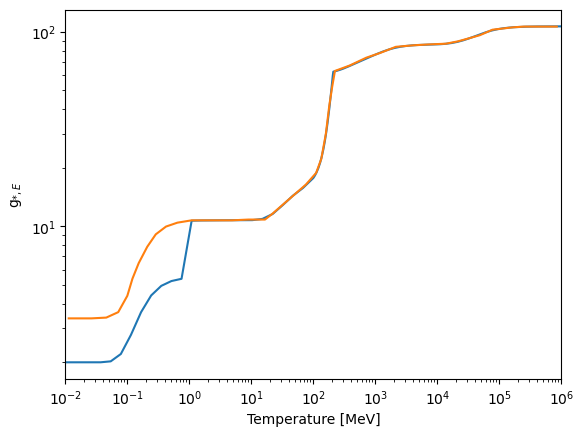

In [20]:
plt.plot(Temp_grid, g_star_E_EM + np.heaviside(Temp_grid - 1.0, 0)*6*0.875) #two curves should aagree above 1 MeV when you add back 6 nuetrino dof
plt.plot(*husdal_fig6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Temperature [MeV]')
plt.ylabel(r'g$_{*,E}$')

plt.xlim(1e-2, 1e6)


In [ ]:
plt.plot(Temp_grid, g_star_E_dat_qgp, label='QGP')
plt.plot(Temp_grid, g_star_E_dat_had, label='Hadron Gas Model')
plt.xlabel('Temperature [MeV]')
plt.ylabel(r'g$_{*,E}$')
plt.yscale('log')
plt.ylim(16, 100)
plt.xlim(100, 300)

### Find QCD PT temp from g_star curve intersection

In [ ]:
from scipy.interpolate import interp1d
g_star_E_dat_qgp_I = interp1d(Temp_grid[50:100], g_star_E_dat_qgp[50:100])
g_star_E_dat_had_I = interp1d(Temp_grid[50:100], g_star_E_dat_had[50:100])

In [ ]:
from scipy.optimize import brentq

root = brentq(lambda T: g_star_E_dat_qgp_I(T) - g_star_E_dat_had_I(T), 180, 220)
print(root)

In [ ]:
def g_star_s_lep(T):
    return 0.25*(3*g_star_E_leptons(T) + g_star_P_leptons(T))

In [ ]:
((2+g_star_s_lep(1e-2))/(2+g_star_s_lep(2)))**(1/3)

In [ ]:
2+g_star_s_lep(1)

In [ ]:
2+g_star_s_lep(1e-2)

In [ ]:
(2/5.5)**(1/3)

In [ ]:
0.25*(3*g_star_E_fd(1, 105, 4) + g_star_P_fd(1, 105, 4))